In [5]:
import os
import json
import matplotlib.pyplot as plt
from matplotlib import font_manager
font_path = "/usr/share/fonts/truetype/msttcorefonts/Arial.ttf"
font_manager.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "Arial"


In [6]:
import matplotlib.font_manager as fm
font_manager.fontManager.addfont("/usr/share/fonts/truetype/msttcorefonts/Arial_Bold.ttf")
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.weight"] = "bold"
print([f.name for f in fm.fontManager.ttflist if "Arial" in f.name])

['Arial', 'Arial', 'Arial', 'Arial', 'Arial', 'Arial']


Power: 5000
  LQR avg across RTR setpoints: 5038.17619047619
  FC-GPU avg across RTR setpoints: 5939.266666666666
  DFS avg across RTR setpoints: 5021.769444444444
Power: 5500
  LQR avg across RTR setpoints: 5522.0142857142855
  FC-GPU avg across RTR setpoints: 5944.291111111112
  DFS avg across RTR setpoints: 5490.223611111111
Power: 6000
  LQR avg across RTR setpoints: 5996.511111111111
  FC-GPU avg across RTR setpoints: 5942.8
  DFS avg across RTR setpoints: 6024.273611111111
Power: 6500
  LQR avg across RTR setpoints: 6510.855555555556
  FC-GPU avg across RTR setpoints: 5961.733333333333
  DFS avg across RTR setpoints: 6509.525
Power: 7000
  LQR avg across RTR setpoints: 7040.688888888889
  FC-GPU avg across RTR setpoints: 5964.644444444444
  DFS avg across RTR setpoints: 7026.622222222222


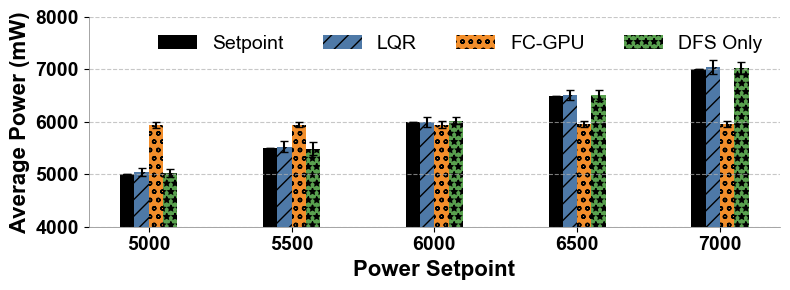

In [9]:
# LQR vs FC vs DFS Power Revision 2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from pathlib import Path

# ---------- FONT ----------
font_manager.fontManager.addfont("/usr/share/fonts/truetype/msttcorefonts/Arial_Bold.ttf")
plt.rcParams.update({
    "font.family": "Arial",
    "font.weight": "normal",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.titlesize": 16,
    "legend.fontsize": 14,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})

# ---------------- CONFIG ----------------
l_root = Path("logs/Full_LQR/hist_stereo_mm/")
f_root = Path("logs/Full_FC/hist_stereo_mm/")
d_root = Path("logs/Full_DFS/hist_stereo_mm/")

setpoints = [0.70, 0.75, 0.80, 0.85, 0.90]
power = [5000, 5500, 6000, 6500, 7000]
save_path = Path("figures")

colors = ['black', '#4E79A7', '#F28E2B', '#59A14F']
hatches = ["", "//", "oo", "**"]
names = ["Setpoint", "LQR", "FC-GPU", "DFS Only"]

# ---------------- HELPERS ----------------
def read_data(filepath: Path):
    if not filepath.exists():
        print(f"Missing: {filepath}")
        return np.array([])
    try:
        return np.loadtxt(filepath)
    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return np.array([])

def safe_slice(arr):
    if arr.size == 0:
        return arr
    return arr[100:-1] if arr.size > 101 else arr

def find_setpoint_dir(root: Path, sp1: float, sp2):
    candidates = [
        root / f"setpoint_{sp1:.2f}",
        root / f"setpoint_{sp2}_{sp1:.2f}_{sp1:.2f}_{sp1:.2f}",
        root / f"setpoint_{sp2}_0.90_0.90_0.90",
    ]
    for c in candidates:
        if c.exists():
            return c
    print(f"No directory found for {root} setpoint {sp1:.2f}, power {sp2}")
    return None

def fc_or_prop_avg_power(root: Path, prefix: str, sp2):
    means = []
    stds = []

    for sp1 in setpoints:
        run_dir = find_setpoint_dir(root, sp1, sp2)
        if run_dir is None:
            means.append(np.nan)
            stds.append(np.nan)
            continue

        power_reading = read_data(run_dir / f"{prefix}_finalpowervalues.txt")
        power_reading = safe_slice(power_reading)

        if power_reading.size == 0:
            means.append(np.nan)
            stds.append(np.nan)
            continue

        means.append(float(np.mean(power_reading)))
        stds.append(float(np.std(power_reading)))

    return np.array(means), np.array(stds)

def avg_across_setpoints(root: Path, prefix: str, p_sp: int):
    means, stds = fc_or_prop_avg_power(root, prefix, p_sp)

    valid = ~np.isnan(means)
    if not np.any(valid):
        return np.nan, np.nan

    # average the means across the RTR setpoints
    avg_mean = float(np.mean(means[valid]))

    # combine variability in a simple way for plotting
    avg_std = float(np.mean(stds[valid])) if np.any(~np.isnan(stds[valid])) else np.nan

    return avg_mean, avg_std

# ---------------- COLLECT ----------------
lqr_group_means = []
lqr_group_stds  = []

fc_group_means = []
fc_group_stds  = []

dfs_group_means = []
dfs_group_stds  = []

setpoint_group_means = []
setpoint_group_stds  = []

for p_sp in power:
    print("Power:", p_sp)

    l_mean, l_std = avg_across_setpoints(l_root, "LQR", p_sp)
    f_mean, f_std = avg_across_setpoints(f_root, "FC_GPU", p_sp)
    d_mean, d_std = avg_across_setpoints(d_root, "DFS", p_sp)

    lqr_group_means.append(l_mean)
    lqr_group_stds.append(l_std)

    fc_group_means.append(f_mean)
    fc_group_stds.append(f_std)

    dfs_group_means.append(d_mean)
    dfs_group_stds.append(d_std)

    setpoint_group_means.append(float(p_sp))
    setpoint_group_stds.append(0.0)

    print("  LQR avg across RTR setpoints:", l_mean)
    print("  FC-GPU avg across RTR setpoints:", f_mean)
    print("  DFS avg across RTR setpoints:", d_mean)

lqr_group_means = np.array(lqr_group_means)
lqr_group_stds  = np.array(lqr_group_stds)

fc_group_means = np.array(fc_group_means)
fc_group_stds  = np.array(fc_group_stds)

dfs_group_means = np.array(dfs_group_means)
dfs_group_stds  = np.array(dfs_group_stds)

setpoint_group_means = np.array(setpoint_group_means)
setpoint_group_stds  = np.array(setpoint_group_stds)

# ---------------- PLOT ----------------
fig, ax = plt.subplots(figsize=(8, 3))

x = np.arange(len(power))
bar_width = 0.10

all_means = [
    setpoint_group_means,
    lqr_group_means,
    fc_group_means,
    dfs_group_means,
    
]
all_stds = [
    setpoint_group_stds,
    lqr_group_stds,
    fc_group_stds,
    dfs_group_stds,
    
]

for i in range(4):
    ax.bar(
        x + (i - 1.5) * bar_width,
        all_means[i],
        bar_width,
        yerr=all_stds[i],
        color=colors[i],
        hatch=hatches[i],
        capsize=3,
        linewidth=0.8,
        label=names[i],
    )

ax.set_xlabel("Power Setpoint", fontsize=16, fontweight="bold")
ax.set_ylabel("Average Power (mW)", fontsize=16, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([f"{p}" for p in power], fontweight="bold")

ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('gray')
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_color('gray')
ax.spines['bottom'].set_linewidth(0.5)

ax.legend(frameon=False, ncols=4, fontsize=14)
ax.set_ylim([4000, 8000])

plt.xticks(fontsize=14, fontweight="bold")
plt.yticks(fontsize=14, fontweight="bold")
plt.tight_layout()

save_path.mkdir(exist_ok=True)
plt.savefig(
    save_path / "jetson_power_barplot.pdf",
    dpi=300,
    bbox_inches='tight',
    format='pdf'
)
plt.show()

RTR setpoint: 0.7
  LQR avg across power: 0.700107213919414
  FC-GPU avg across power: 0.7000859238095238
  DFS avg across power: 0.7710981743589743
RTR setpoint: 0.75
  LQR avg across power: 0.7500268307692306
  FC-GPU avg across power: 0.749957264126984
  DFS avg across power: 0.7726009282051282
RTR setpoint: 0.8
  LQR avg across power: 0.7998893791208792
  FC-GPU avg across power: 0.7998917965079365
  DFS avg across power: 0.773388841025641
RTR setpoint: 0.85
  LQR avg across power: 0.850190875091575
  FC-GPU avg across power: 0.8498599403174604
  DFS avg across power: 0.7715570307692308
RTR setpoint: 0.9
  LQR avg across power: 0.9000369384615384
  FC-GPU avg across power: 0.8998717041269841
  DFS avg across power: 0.7731401846153846


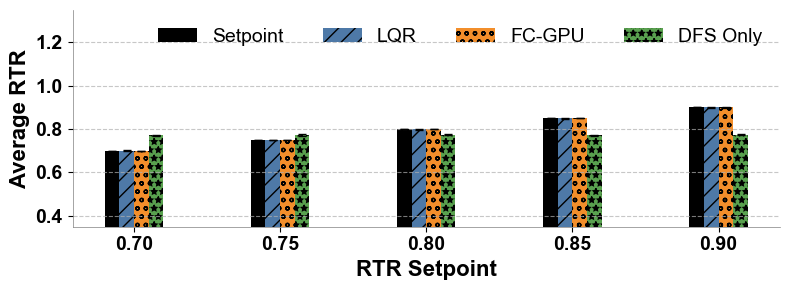

In [10]:
# LQR vs FC vs DFS RTR REVISION 3 (X = RTR setpoint, avg over power)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from pathlib import Path

# ---------- FONT ----------
font_manager.fontManager.addfont("/usr/share/fonts/truetype/msttcorefonts/Arial_Bold.ttf")
plt.rcParams.update({
    "font.family": "Arial",
    "font.weight": "normal",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "legend.fontsize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

# ---------------- CONFIG ----------------
l_root = Path("logs/Full_LQR/hist_stereo_mm/")
f_root = Path("logs/Full_FC/hist_stereo_mm/")
d_root = Path("logs/Full_DFS/hist_stereo_mm/")

setpoints = [0.70, 0.75, 0.80, 0.85, 0.90]
power = [5000, 5500, 6000, 6500, 7000]
save_path = Path("figures")

colors = ['black', '#4E79A7', '#F28E2B', '#59A14F']
hatches = ["", "//", "oo", "**"]
names = ["Setpoint", "LQR", "FC-GPU", "DFS Only"]

# ---------------- HELPERS ----------------
def read_data(filepath: Path):
    if not filepath.exists():
        print(f"Missing: {filepath}")
        return np.array([])
    try:
        return np.loadtxt(filepath)
    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return np.array([])

def safe_slice(arr):
    if arr.size == 0:
        return arr
    return arr[100:-1] if arr.size > 101 else arr

def find_setpoint_dir(root: Path, sp1: float, sp2):
    candidates = [
        root / f"setpoint_{sp1:.2f}",
        root / f"setpoint_{sp2}_{sp1:.2f}_{sp1:.2f}_{sp1:.2f}",
        root / f"setpoint_{sp2}_0.90_0.90_0.90",
    ]
    for c in candidates:
        if c.exists():
            return c
    print(f"No directory found for {root} setpoint {sp1:.2f}, power {sp2}")
    return None

def fc_or_prop_avg_rtr(root: Path, prefix: str, sp1):
    means = []
    stds = []

    for p_sp in power:
        run_dir = find_setpoint_dir(root, sp1, p_sp)
        if run_dir is None:
            means.append(np.nan)
            stds.append(np.nan)
            continue

        t1 = read_data(run_dir / f"{prefix}_t1_rtr.txt")
        t2 = read_data(run_dir / f"{prefix}_t2_rtr.txt")
        t3 = read_data(run_dir / f"{prefix}_t3_rtr.txt")

        t1 = safe_slice(t1)
        t2 = safe_slice(t2)
        t3 = safe_slice(t3)

        n = min(len(t1), len(t2), len(t3))
        if n == 0:
            means.append(np.nan)
            stds.append(np.nan)
            continue

        avg_trace = (t1[:n] + t2[:n] + t3[:n]) / 3.0
        means.append(float(np.mean(avg_trace)))
        stds.append(float(np.std(avg_trace)))

    return np.array(means), np.array(stds)

def avg_across_power(root: Path, prefix: str, sp1):
    means, stds = fc_or_prop_avg_rtr(root, prefix, sp1)

    valid = ~np.isnan(means)
    if not np.any(valid):
        return np.nan, np.nan

    avg_mean = float(np.mean(means[valid]))
    avg_std = float(np.mean(stds[valid])) if np.any(~np.isnan(stds[valid])) else np.nan

    return avg_mean, avg_std

# ---------------- COLLECT ----------------
setpoint_group_means = []
setpoint_group_stds  = []

lqr_group_means = []
lqr_group_stds  = []

fc_group_means = []
fc_group_stds  = []

dfs_group_means = []
dfs_group_stds  = []

for sp1 in setpoints:
    print("RTR setpoint:", sp1)

    l_mean, l_std = avg_across_power(l_root, "LQR", sp1)
    f_mean, f_std = avg_across_power(f_root, "FC_GPU", sp1)
    d_mean, d_std = avg_across_power(d_root, "DFS", sp1)

    setpoint_group_means.append(sp1)
    setpoint_group_stds.append(0.0)

    lqr_group_means.append(l_mean)
    lqr_group_stds.append(l_std)

    fc_group_means.append(f_mean)
    fc_group_stds.append(f_std)

    dfs_group_means.append(d_mean)
    dfs_group_stds.append(d_std)

    print("  LQR avg across power:", l_mean)
    print("  FC-GPU avg across power:", f_mean)
    print("  DFS avg across power:", d_mean)

# convert to arrays
setpoint_group_means = np.array(setpoint_group_means)
lqr_group_means = np.array(lqr_group_means)
fc_group_means = np.array(fc_group_means)
dfs_group_means = np.array(dfs_group_means)

setpoint_group_stds = np.array(setpoint_group_stds)
lqr_group_stds = np.array(lqr_group_stds)
fc_group_stds = np.array(fc_group_stds)
dfs_group_stds = np.array(dfs_group_stds)

# ---------------- PLOT ----------------
fig, ax = plt.subplots(figsize=(8, 3))

x = np.arange(len(setpoints))
bar_width = 0.10

all_means = [
    setpoint_group_means,
    lqr_group_means,
    fc_group_means,
    dfs_group_means,
]
all_stds = [
    setpoint_group_stds,
    lqr_group_stds,
    fc_group_stds,
    dfs_group_stds,
]

for i in range(4):
    ax.bar(
        x + (i - 1.5) * bar_width,
        all_means[i],
        bar_width,
        yerr=all_stds[i],
        color=colors[i],
        hatch=hatches[i],
        capsize=3,
        linewidth=0.8,
        label=names[i],
    )

ax.set_xlabel("RTR Setpoint", fontsize=16, fontweight="bold")
ax.set_ylabel("Average RTR", fontsize=16, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([f"{sp:.2f}" for sp in setpoints], fontweight="bold")

ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('gray')
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_color('gray')
ax.spines['bottom'].set_linewidth(0.5)

ax.legend(frameon=False, ncols=4, fontsize=14)
ax.set_ylim([0.35, 1.35])

plt.xticks(fontsize=14, fontweight="bold")
plt.yticks(fontsize=14, fontweight="bold")

plt.tight_layout()
save_path.mkdir(exist_ok=True)
plt.savefig(
    save_path / "jetson_rtr_barplot.pdf",
    dpi=300,
    bbox_inches='tight',
    format='pdf'
)
plt.show()